# TP 3: Logistic_Regression

**Group 1: I3-AMS-TPB**<br>

**Name: NUON CHANVATHANA**<br>

**ID: e20230118**


Remarks: All models here should be built from scratch.


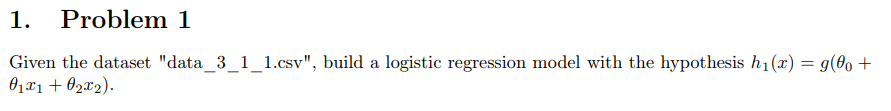

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df = pd.read_csv('data_3_1_1.csv')
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [98]:
X_train = df[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test = df[['x1', 'x2']].drop(df.sample(frac=0.8, random_state=42).index).values
y_train = df['class'].sample(frac=0.8, random_state=42).values
y_test = df['class'].drop(df.sample(frac=0.8, random_state=42).index).values
m, n = X_train.shape
print(f"Number of training examples: {m}")

Number of training examples: 80


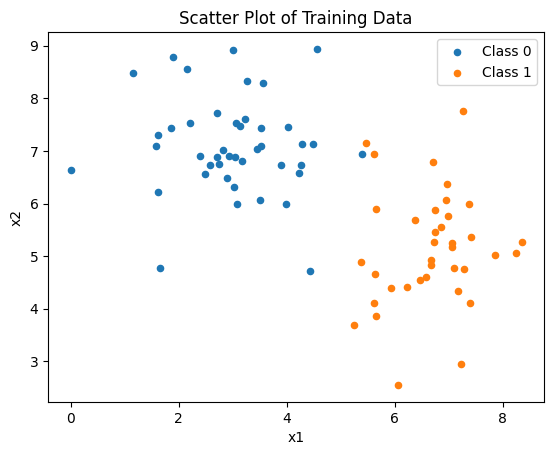

In [99]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [100]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cost function
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost_sum = 0
    epsilon = 1e-15

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, epsilon, 1 - epsilon)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1/m) * cost_sum

#gradient function
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i][j]


    grad_w = (1/m) * grad_w
    grad_b = (1/m) * grad_b
    return grad_w, grad_b

#gradient descent function
def gradient_descent(X, y, alpha, iterations):
    m,n = X.shape
    w = np.zeros(n)
    b = 0

    for it in range(iterations):
        grad_w, grad_b = gradient_function(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if it % 100 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {it}: Cost {cost_function(X, y, w, b)}")

    return w, b
                      

In [101]:
def predict(X, w, b):
    m = X.shape[0]
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds


In [102]:
def get_confusion_matrix(y_true, y_pred):
    # 1. Identify all unique classes and sort them for consistent indexing
    classes = sorted(list(set(y_true) | set(y_pred)))
    class_to_idx = {val: i for i, val in enumerate(classes)}
    size = len(classes)
    
    # 2. Initialize an empty (zeroed) square matrix
    matrix = [[0] * size for _ in range(size)]
    
    # 3. Fill the matrix by iterating through both lists simultaneously
    for actual, predicted in zip(y_true, y_pred):
        row = class_to_idx[actual]
        col = class_to_idx[predicted]
        matrix[row][col] += 1
        
    return matrix, classes

In [103]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, num_iterations)

predictions = predict(X_train, final_w, final_b)

accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6826646054751653
Iteration 100: Cost 0.2759924880250862
Iteration 200: Cost 0.18878848948646876
Iteration 300: Cost 0.15170856633036525
Iteration 400: Cost 0.13105931164809306
Iteration 500: Cost 0.11783098053288615
Iteration 600: Cost 0.10859825686357083
Iteration 700: Cost 0.1017705640795579
Iteration 800: Cost 0.09650666804070801
Iteration 900: Cost 0.09231886734612019
Iteration 1000: Cost 0.08890439897142438
Iteration 1100: Cost 0.08606507568373661
Iteration 1200: Cost 0.08366555699763552
Iteration 1300: Cost 0.0816101681343138
Iteration 1400: Cost 0.07982929909945036
Iteration 1500: Cost 0.07827105546427442
Iteration 1600: Cost 0.07689593415125585
Iteration 1700: Cost 0.07567331608537875
Iteration 1800: Cost 0.07457908992000285
Iteration 1900: Cost 0.07359400213468617
Iteration 2000: Cost 0.07270248647559838
Iteration 2100: Cost 0.0718918174145391
Iteration 2200: Cost 0.07115148736653142
Iteration 2300: Cost 0.07047274141660136
Iteration 2400: Cost 0.0698482248

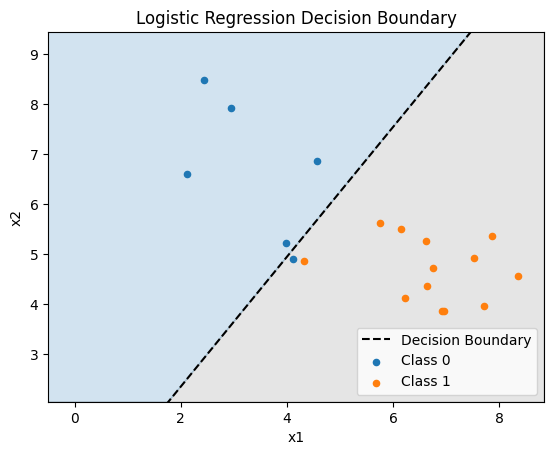

In [104]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

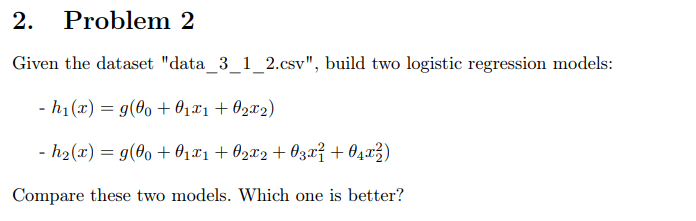

In [105]:
df_2 = pd.read_csv('data_3_1_2.csv')
df_2.head()

,x1,x2,class
0,9.076,3.721,0
1,6.809,3.930,0
2,8.256,2.851,1
3,8.461,3.145,1
4,6.783,3.188,1


In [106]:
df_2.shape

(200, 3)

In [107]:
X_train_1 = df_2[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test_1 = df_2[['x1', 'x2']].drop(df_2.sample(frac=0.8, random_state=42).index).values
#this is correct because we use random_state=42 in both sampling and dropping to ensure the same split
y_train = df_2['class'].sample(frac=0.8, random_state=42).values
y_test = df_2['class'].drop(df_2.sample(frac=0.8, random_state=42).index).values
X_temp = df_2[['x1', 'x2']].copy()

X_temp['x1_squared'] = X_temp['x1'] ** 2
X_temp['x2_squared'] = X_temp['x2'] ** 2

X_train_2 = X_temp.sample(frac=0.8, random_state=42).values
X_test_2 = X_temp.drop(X_temp.sample(frac=0.8, random_state=42).index).values

m, n = X_train_1.shape
print("Shape of X_train_1:", X_train_1.shape)
print("Shape of X_train_2:", X_train_2.shape)
print(f"Number of training examples: {m}")

Shape of X_train_1: (160, 2)
Shape of X_train_2: (160, 4)
Number of training examples: 160


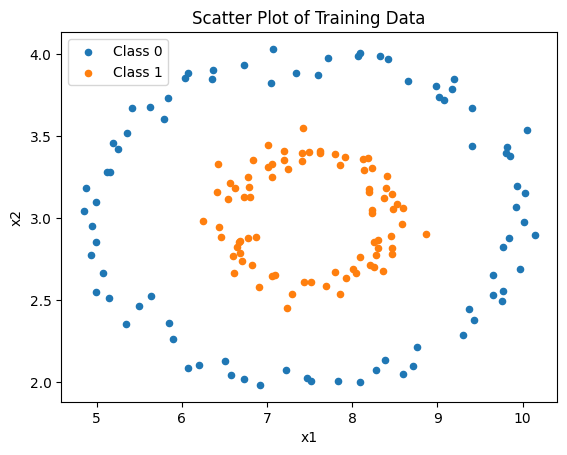

In [108]:
plt.scatter(X_train_1[y_train == 0, 0], X_train_1[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_1[y_train == 1, 0], X_train_1[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [109]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train_1, y_train, learning_rate, num_iterations)

predictions = predict(X_train_1, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931470302667748
Iteration 100: Cost 0.6931346088811051
Iteration 200: Cost 0.6931249301799489
Iteration 300: Cost 0.6931173683780141
Iteration 400: Cost 0.6931114538583227
Iteration 500: Cost 0.6931068212378306
Iteration 600: Cost 0.6931031862328727
Iteration 700: Cost 0.6931003276583099
Iteration 800: Cost 0.6930980734217362
Iteration 900: Cost 0.6930962896263734
Iteration 1000: Cost 0.693094872092793
Iteration 1100: Cost 0.6930937397626127
Iteration 1200: Cost 0.6930928295664409
Iteration 1300: Cost 0.6930920924310171
Iteration 1400: Cost 0.6930914901726805
Iteration 1500: Cost 0.6930909930804013
Iteration 1600: Cost 0.6930905780353057
Iteration 1700: Cost 0.6930902270475929
Iteration 1800: Cost 0.6930899261182021
Iteration 1900: Cost 0.6930896643531316
Iteration 2000: Cost 0.6930894332743394
Iteration 2100: Cost 0.6930892262835813
Iteration 2200: Cost 0.6930890382452463
Iteration 2300: Cost 0.6930888651617764
Iteration 2400: Cost 0.69308870392112
Iteration 2500:

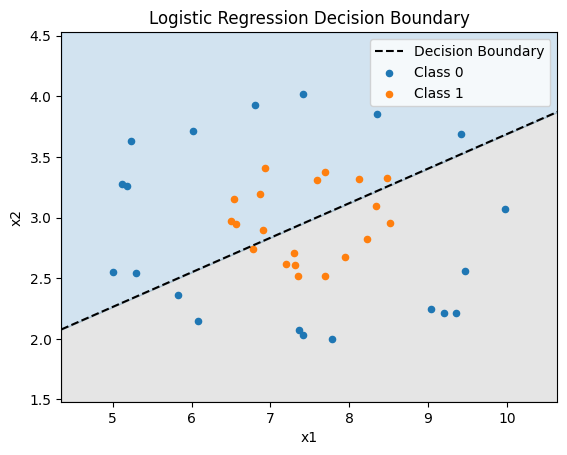

In [110]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train_1[:, 0].min() - 0.5, X_train_1[:, 0].max() + 0.5
ymin, ymax = X_train_1[:, 1].min() - 0.5, X_train_1[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test_1[y_test == 0, 0], X_test_1[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test_1[y_test == 1, 0], X_test_1[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [111]:
get_confusion_matrix(y_train,predictions)

([[41, 39], [42, 38]], [np.int64(0), np.int64(1)])

In [112]:
learning_rate = 0.01
num_iterations = 10000
# Simple Z-score normalization
X_scaled = (X_train_2 - np.mean(X_train_2, axis=0)) / np.std(X_train_2, axis=0)
final_w, final_b = gradient_descent(X_scaled, y_train, learning_rate, num_iterations)
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931233390718421
Iteration 100: Cost 0.6912459013111883
Iteration 200: Cost 0.6899088546024128
Iteration 300: Cost 0.6887697877890578
Iteration 400: Cost 0.6877042570049292
Iteration 500: Cost 0.6866669572624695
Iteration 600: Cost 0.685641363391274
Iteration 700: Cost 0.6846214376306212
Iteration 800: Cost 0.6836049700296309
Iteration 900: Cost 0.6825911493216429
Iteration 1000: Cost 0.6815796756948479
Iteration 1100: Cost 0.6805704364472441
Iteration 1200: Cost 0.6795633873488406
Iteration 1300: Cost 0.6785585092318287
Iteration 1400: Cost 0.6775557921037715
Iteration 1500: Cost 0.6765552293330077
Iteration 1600: Cost 0.6755568155205669
Iteration 1700: Cost 0.6745605457214366
Iteration 1800: Cost 0.6735664151596978
Iteration 1900: Cost 0.6725744191244015
Iteration 2000: Cost 0.6715845529315573
Iteration 2100: Cost 0.6705968119102957
Iteration 2200: Cost 0.6696111913978626
Iteration 2300: Cost 0.6686276867378299
Iteration 2400: Cost 0.6676462932794786
Iteration 250

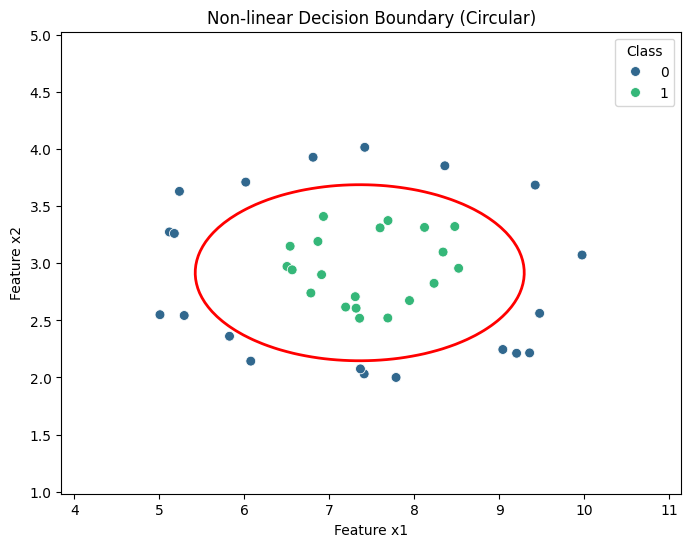

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Your weights and bias
weights = np.array([1.53313569, 1.48200905, -1.56888842, -1.53104136])
bias = -0.0001571431545626939

# 2. Get mean and std from your training data (CRITICAL for matching the scaling)
mu = np.mean(X_train_2, axis=0)
std = np.std(X_train_2, axis=0)

# 3. Create a grid of points over the range of your data
x_range = np.linspace(X_train_2[:, 0].min() - 1, X_train_2[:, 0].max() + 1, 100)
y_range = np.linspace(X_train_2[:, 1].min() - 1, X_train_2[:, 1].max() + 1, 100)
xx, yy = np.meshgrid(x_range, y_range)

# 4. Prepare the grid features to match your X_train_2 structure [x1, x2, x1^2, x2^2]
grid_points = np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2]

# 5. Scale the grid points using the training mu and std
grid_points_scaled = (grid_points - mu) / std

# 6. Calculate Z (the linear part of the logistic regression: weights * X + bias)
# We plot the boundary where Z = 0
Z = grid_points_scaled @ weights + bias
Z = Z.reshape(xx.shape)

# 7. Plot using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_2[:, 0], y=X_test_2[:, 1], hue=y_test, palette='viridis', s=50)
plt.contour(xx, yy, Z, levels=[0], colors='red', linewidths=2)

plt.title("Non-linear Decision Boundary (Circular)")
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.legend(title='Class')
plt.show()

In [114]:
final_w,final_b

(array([ 1.52623082,  1.44467713, -1.58875164, -1.53170137]),
 np.float64(-0.0003815245207169876))

In [115]:
get_confusion_matrix(y_train,predictions)

([[74, 6], [0, 80]], [np.int64(0), np.int64(1)])

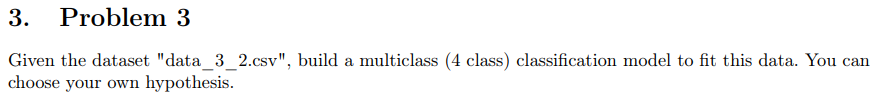

In [116]:
data = pd.read_csv('data_3_2.csv')
data.head()

,x1,x2,class
0,10.52,0.65,3
1,1.46,-1.25,2
2,1.50,0.56,2
3,-1.36,2.50,0
4,11.16,5.19,1


In [117]:
X = data[['x1', 'x2']].values
y = data['class'].values
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]
classes = np.unique(y)
num_classes = len(classes)
print(f"Unique classes: {classes}")

Unique classes: [0 1 2 3]


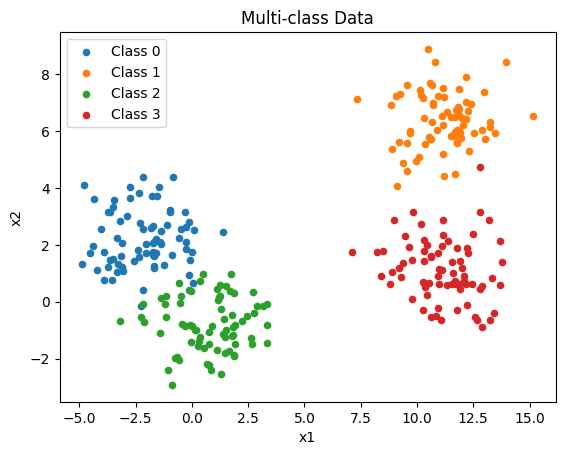

In [118]:
for c in classes:
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multi-class Data')
plt.legend()
plt.show()


In [119]:
weights = []
biases = []

for c in classes:
    print(f"Training classifier for class {c}")

    # Create binary labels
    y_binary = (y == c).astype(int)

    w, b = gradient_descent(X_train, y_binary[:80], alpha=0.1, iterations=1000)

    weights.append(w)
    biases.append(b)

weights = np.array(weights)
biases = np.array(biases)

Training classifier for class 0
Iteration 0: Cost 0.2783241631855548
Iteration 100: Cost 0.09976670799984019
Iteration 200: Cost 0.07243471906493712
Iteration 300: Cost 0.0580457280954136
Iteration 400: Cost 0.0489640938584355
Iteration 500: Cost 0.04265631308112958
Iteration 600: Cost 0.03798992078730316
Iteration 700: Cost 0.03437927956591574
Iteration 800: Cost 0.031490446397405746
Iteration 900: Cost 0.02911863091882156
Training classifier for class 1
Iteration 0: Cost 0.6703382892710695
Iteration 100: Cost 0.2546799346738368
Iteration 200: Cost 0.16551941114619712
Iteration 300: Cost 0.1256679115679712
Iteration 400: Cost 0.10266159930249463
Iteration 500: Cost 0.08749854764686368
Iteration 600: Cost 0.07666344039586168
Iteration 700: Cost 0.0684875428655509
Iteration 800: Cost 0.06207154156112658
Iteration 900: Cost 0.05688546331192876
Training classifier for class 2
Iteration 0: Cost 0.40639216113883814
Iteration 100: Cost 0.15210530749887852
Iteration 200: Cost 0.12054986434813

In [120]:
def predict_prob(X, w, b):
    m = X.shape[0]
    probs = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        probs[i] = sigmoid(z)

    return probs

In [121]:
#predict multiclass
def predict_multiclass(X, weights, biases):
    m = X.shape[0]
    num_classes = weights.shape[0]
    probs = np.zeros((m, num_classes))

    for c in range(num_classes):
        probs[:, c] = predict_prob(X, weights[c], biases[c])

    return np.argmax(probs, axis=1)

In [122]:
predictions = predict_multiclass(X_test, weights, biases)

accuracy = np.mean(predictions == y_test) * 100
print(f"\nMulticlass Accuracy: {accuracy:.2f}%")


Multiclass Accuracy: 96.82%


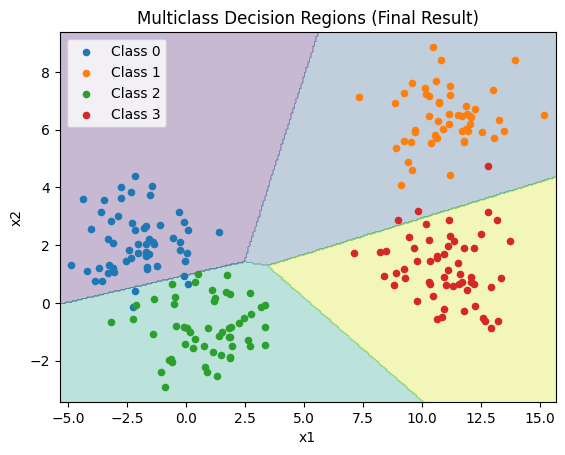

In [123]:
# Plot decision regions 
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict class for each grid point
Z = predict_multiclass(grid, weights, biases)
Z = Z.reshape(xx1.shape)

# Plot decision regions
plt.contourf(xx1, xx2, Z, alpha=0.3)

# Plot actual data points
for c in classes:
    plt.scatter(X_test[y_test == c, 0], X_test[y_test == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multiclass Decision Regions (Final Result)')
plt.legend()
plt.show()

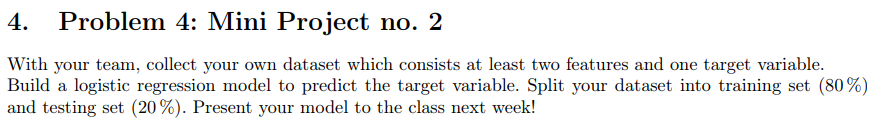

## we do a survey about people preference study mode in person vs online  

In [124]:
df = pd.read_csv('Learning Mode Preference (Responses) - Form Responses 1.csv')

In [125]:
df = df.drop(columns=['Timestamp'])

In [126]:
col = ['study_mode','friend','solo_study','teacher_factor','introvert_level']
df.columns = col

In [127]:
df['study_mode'] = df['study_mode'].map({'IN-PERSON': 0, 'ONLINE': 1})

In [128]:
df

,study_mode,friend,solo_study,teacher_factor,introvert_level
0,0,20,8,10,8
1,1,1,8,6,6
2,0,3,5,7,7
3,1,0,10,8,3
4,0,12,7,9,5
5,0,1,6,6,8
6,0,3,7,8,8
7,0,3,5,8,3
8,0,5,9,7,5
9,0,3,4,8,10


In [129]:
df.describe()

,study_mode,friend,solo_study,teacher_factor,introvert_level
count,18.000000,18.000000,18.000000,18.000000,18.000000
mean,0.277778,37.166667,7.388889,7.944444,6.388889
std,0.460889,129.385993,1.719743,1.433721,1.944491
min,0.000000,0.000000,4.000000,5.000000,3.000000
25%,0.000000,3.000000,6.250000,7.000000,5.000000
50%,0.000000,5.000000,7.500000,8.000000,6.500000
75%,0.750000,11.500000,8.750000,9.000000,8.000000
max,1.000000,555.000000,10.000000,10.000000,10.000000


In [130]:
x_train = df[['friend','solo_study','teacher_factor','introvert_level']].sample(frac = 0.8, random_state=42).values
y_train = df['study_mode'].sample(frac = 0.8, random_state=42).values
x_test = df[['friend','solo_study','teacher_factor','introvert_level']].drop(df.sample(frac = 0.8, random_state=42).index).values
y_test = df['study_mode'].drop(df.sample(frac = 0.8, random_state=42).index).values
# the random state is the same so we don't need to worry about our data split being inconsistent between features and labels


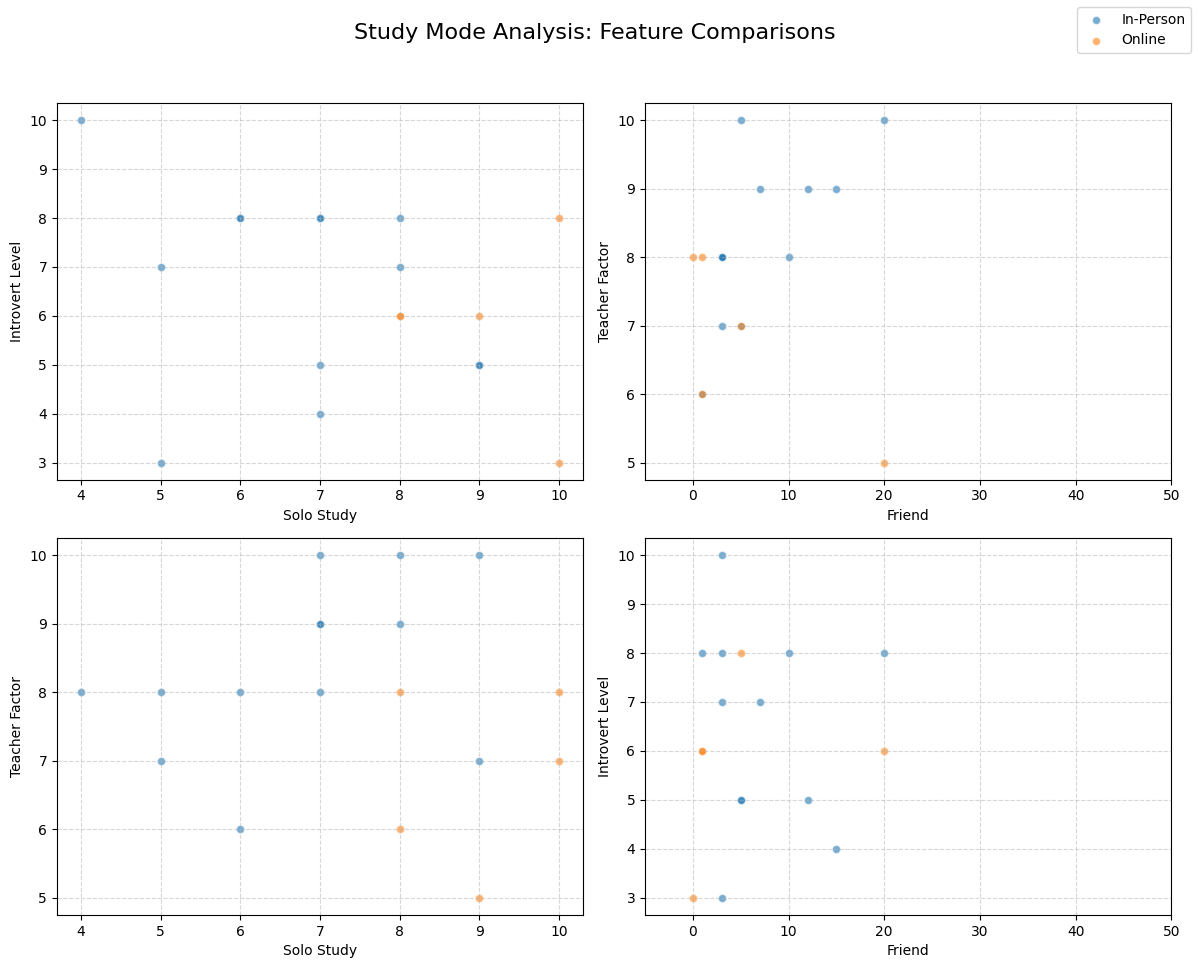

In [131]:
import matplotlib.pyplot as plt

# Setup the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Study Mode Analysis: Feature Comparisons', fontsize=16)

# Define our feature pairs for the 4 plots
pairs = [
    ('solo_study', 'introvert_level'),
    ('friend', 'teacher_factor'),
    ('solo_study', 'teacher_factor'),
    ('friend', 'introvert_level')
]

# Loop through the axes and pairs to plot
for i, ax in enumerate(axes.flat):
    x_feat, y_feat = pairs[i]
    
    # Plot Class 0 (In-Person)
    ax.scatter(df[df['study_mode'] == 0][x_feat], 
               df[df['study_mode'] == 0][y_feat], 
               c='tab:blue', label='In-Person', alpha=0.6, edgecolors='w')
    
    # Plot Class 1 (Online)
    ax.scatter(df[df['study_mode'] == 1][x_feat], 
               df[df['study_mode'] == 1][y_feat], 
               c='tab:orange', label='Online', alpha=0.6, edgecolors='w')
    
    ax.set_xlabel(x_feat.replace('_', ' ').title())
    ax.set_ylabel(y_feat.replace('_', ' ').title())
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Handle the 'friend' outlier so the plot is readable
    if x_feat == 'friend':
        ax.set_xlim(-5, 50) # Clipping the X-axis to focus on the bulk of data
    if y_feat == 'friend':
        ax.set_ylim(-5, 50)

# Add a single legend for the whole figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [132]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(x_train, y_train, learning_rate, num_iterations)

Iteration 0: Cost 0.45014851505260683
Iteration 100: Cost 0.2941346320896599
Iteration 200: Cost 0.2529910664178743
Iteration 300: Cost 0.2303522539224117
Iteration 400: Cost 0.2151976822220305
Iteration 500: Cost 0.20403554096829757
Iteration 600: Cost 0.1953336908621144
Iteration 700: Cost 0.18828564310434115
Iteration 800: Cost 0.18241546554407528
Iteration 900: Cost 0.17741961910628415
Iteration 1000: Cost 0.17309340129710502
Iteration 1100: Cost 0.1692928568801455
Iteration 1200: Cost 0.16591339589191956
Iteration 1300: Cost 0.16287701406329613
Iteration 1400: Cost 0.1601242648424986
Iteration 1500: Cost 0.15760900946409795
Iteration 1600: Cost 0.1552948688539497
Iteration 1700: Cost 0.15315275929300542
Iteration 1800: Cost 0.1511591410010838
Iteration 1900: Cost 0.14929474871351092
Iteration 2000: Cost 0.14754365581136009
Iteration 2100: Cost 0.1458925739571175
Iteration 2200: Cost 0.14433032193585202
Iteration 2300: Cost 0.14284741794880185
Iteration 2400: Cost 0.141435763218757

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_6772\1334519533.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Iteration 6800: Cost 0.10702726836610928
Iteration 6900: Cost 0.10651797029227855
Iteration 7000: Cost 0.10601464671598101
Iteration 7100: Cost 0.10551713252089508
Iteration 7200: Cost 0.10502527039658194
Iteration 7300: Cost 0.10453891035455616
Iteration 7400: Cost 0.1040579092802092
Iteration 7500: Cost 0.10358213051751136
Iteration 7600: Cost 0.10311144348371708
Iteration 7700: Cost 0.10264572331156016
Iteration 7800: Cost 0.10218485051667547
Iteration 7900: Cost 0.10172871068818608
Iteration 8000: Cost 0.10127719420058834
Iteration 8100: Cost 0.1008301959452453
Iteration 8200: Cost 0.10038761507993992
Iteration 8300: Cost 0.0999493547950885
Iteration 8400: Cost 0.09951532209533125
Iteration 8500: Cost 0.09908542759533318
Iteration 8600: Cost 0.09865958532872665
Iteration 8700: Cost 0.09823771256921812
Iteration 8800: Cost 0.09781972966296723
Iteration 8900: Cost 0.09740555987141478
Iteration 9000: Cost 0.09699512922381016
Iteration 9100: Cost 0.09658836637874549
Iteration 9200: Cos

In [133]:
predictions = predict(x_train, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 100.00%


C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_6772\1334519533.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [134]:
get_confusion_matrix(y_train, predictions)

([[10, 0], [0, 4]], [np.int64(0), np.int64(1)])

In [135]:
predictions = predict(x_test, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 75.00%


In [136]:
get_confusion_matrix(y_test, predictions)

([[3, 0], [1, 0]], [np.int64(0), np.int64(1)])

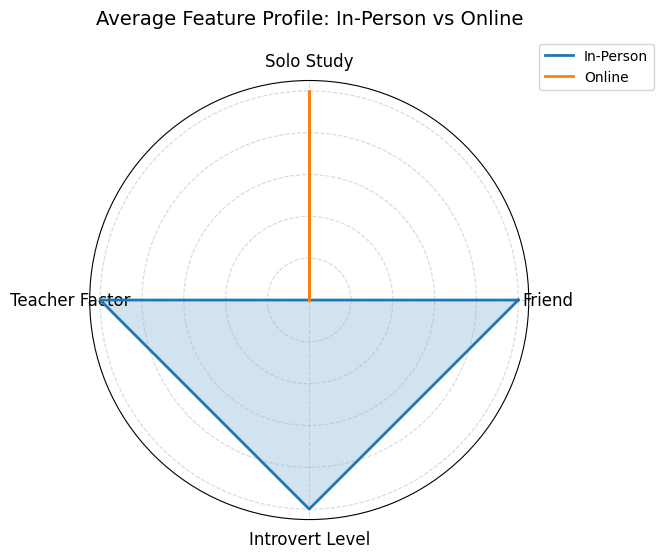

In [137]:
import matplotlib.pyplot as plt
import numpy as np

features = ['friend', 'solo_study', 'teacher_factor', 'introvert_level']
labels = ['Friend', 'Solo Study', 'Teacher Factor', 'Introvert Level']

# Mean of each feature per class
in_person_means = df[df['study_mode'] == 0][features].mean().values
online_means = df[df['study_mode'] == 1][features].mean().values

# Normalize to 0-1 so all features are on the same scale
all_means = np.vstack([in_person_means, online_means])
min_vals = all_means.min(axis=0)
max_vals = all_means.max(axis=0)
in_person_norm = (in_person_means - min_vals) / (max_vals - min_vals + 1e-9)
online_norm = (online_means - min_vals) / (max_vals - min_vals + 1e-9)

# Radar setup — need to close the loop
N = len(features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

in_person_vals = in_person_norm.tolist() + in_person_norm[:1].tolist()
online_vals = online_norm.tolist() + online_norm[:1].tolist()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Plot both classes
ax.plot(angles, in_person_vals, color='tab:blue', linewidth=2, label='In-Person')
ax.fill(angles, in_person_vals, color='tab:blue', alpha=0.2)

ax.plot(angles, online_vals, color='tab:orange', linewidth=2, label='Online')
ax.fill(angles, online_vals, color='tab:orange', alpha=0.2)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels([])  # hide radial numbers, we normalized anyway
ax.set_title('Average Feature Profile: In-Person vs Online', 
             fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Study Mode Preferences')

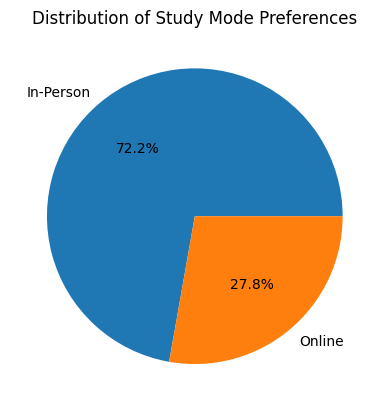

In [138]:
plt.pie(df['study_mode'].value_counts(), labels=['In-Person', 'Online'], autopct='%1.1f%%', colors=['tab:blue', 'tab:orange'])
plt.title('Distribution of Study Mode Preferences')

In [139]:
def random_oversample(X_minority, n_samples, noise_scale=0.05):
    synthetic = []
    for _ in range(n_samples):
        # Pick a random minority sample
        idx = np.random.randint(0, len(X_minority))
        sample = X_minority[idx].copy()
        
        # Add tiny noise so it's not an exact duplicate
        noise = np.random.normal(0, noise_scale, sample.shape)
        synthetic.append(sample + noise)
    
    return np.array(synthetic)

# Split by class
X_minority = x_train[y_train == 1]
X_majority = x_train[y_train == 0]

print(f"Before — In-Person: {len(X_majority)}, Online: {len(X_minority)}")

n_to_generate = len(X_majority) - len(X_minority)
synthetic_samples = random_oversample(X_minority, n_to_generate, noise_scale=0.05)

# Combine
x_train_bal = np.vstack([x_train, synthetic_samples])
y_train_bal = np.hstack([y_train, np.ones(n_to_generate)])

print(f"After  — In-Person: {len(X_majority)}, Online: {len(X_minority) + n_to_generate}")

# Retrain
final_w, final_b = gradient_descent(x_train_bal, y_train_bal, 0.01,10000)

predictions = predict(x_test, final_w, final_b)
accuracy = np.mean(predictions == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Before — In-Person: 10, Online: 4
After  — In-Person: 10, Online: 10
Iteration 0: Cost 0.5514419318319398
Iteration 100: Cost 0.28579014125171787
Iteration 200: Cost 0.23911318234642104
Iteration 300: Cost 0.21423745325029328
Iteration 400: Cost 0.19780973364574728
Iteration 500: Cost 0.1858464158497034
Iteration 600: Cost 0.17662158845021983
Iteration 700: Cost 0.16922919214915294
Iteration 800: Cost 0.16313548313247317
Iteration 900: Cost 0.15800097723044582
Iteration 1000: Cost 0.15359752465132556
Iteration 1100: Cost 0.14976526866341183
Iteration 1200: Cost 0.14638846857333995
Iteration 1300: Cost 0.1433810716292775
Iteration 1400: Cost 0.1406776776673209
Iteration 1500: Cost 0.1382276532617547
Iteration 1600: Cost 0.1359911693664667
Iteration 1700: Cost 0.13393645873233626
Iteration 1800: Cost 0.1320378720954294
Iteration 1900: Cost 0.13027447211956897
Iteration 2000: Cost 0.1286289981596659
Iteration 2100: Cost 0.1270870921333369
Iteration 2200: Cost 0.12563671164452053
Iteration

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_6772\1334519533.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Iteration 5700: Cost 0.09820254396144724
Iteration 5800: Cost 0.09770997904586169
Iteration 5900: Cost 0.0972252174265554
Iteration 6000: Cost 0.09674796975446287
Iteration 6100: Cost 0.09627796324480181
Iteration 6200: Cost 0.09581494045500641
Iteration 6300: Cost 0.09535865817145284
Iteration 6400: Cost 0.0949088863937029
Iteration 6500: Cost 0.09446540740631829
Iteration 6600: Cost 0.0940280149294502
Iteration 6700: Cost 0.09359651334041248
Iteration 6800: Cost 0.0931707169593234
Iteration 6900: Cost 0.09275044939266715
Iteration 7000: Cost 0.0923355429292968
Iteration 7100: Cost 0.09192583798398893
Iteration 7200: Cost 0.09152118258418324
Iteration 7300: Cost 0.09112143189599131
Iteration 7400: Cost 0.09072644778596747
Iteration 7500: Cost 0.09033609841549006
Iteration 7600: Cost 0.08995025786491563
Iteration 7700: Cost 0.08956880578495498
Iteration 7800: Cost 0.08919162707296473
Iteration 7900: Cost 0.08881861157207108
Iteration 8000: Cost 0.08844965379124604
Iteration 8100: Cost 

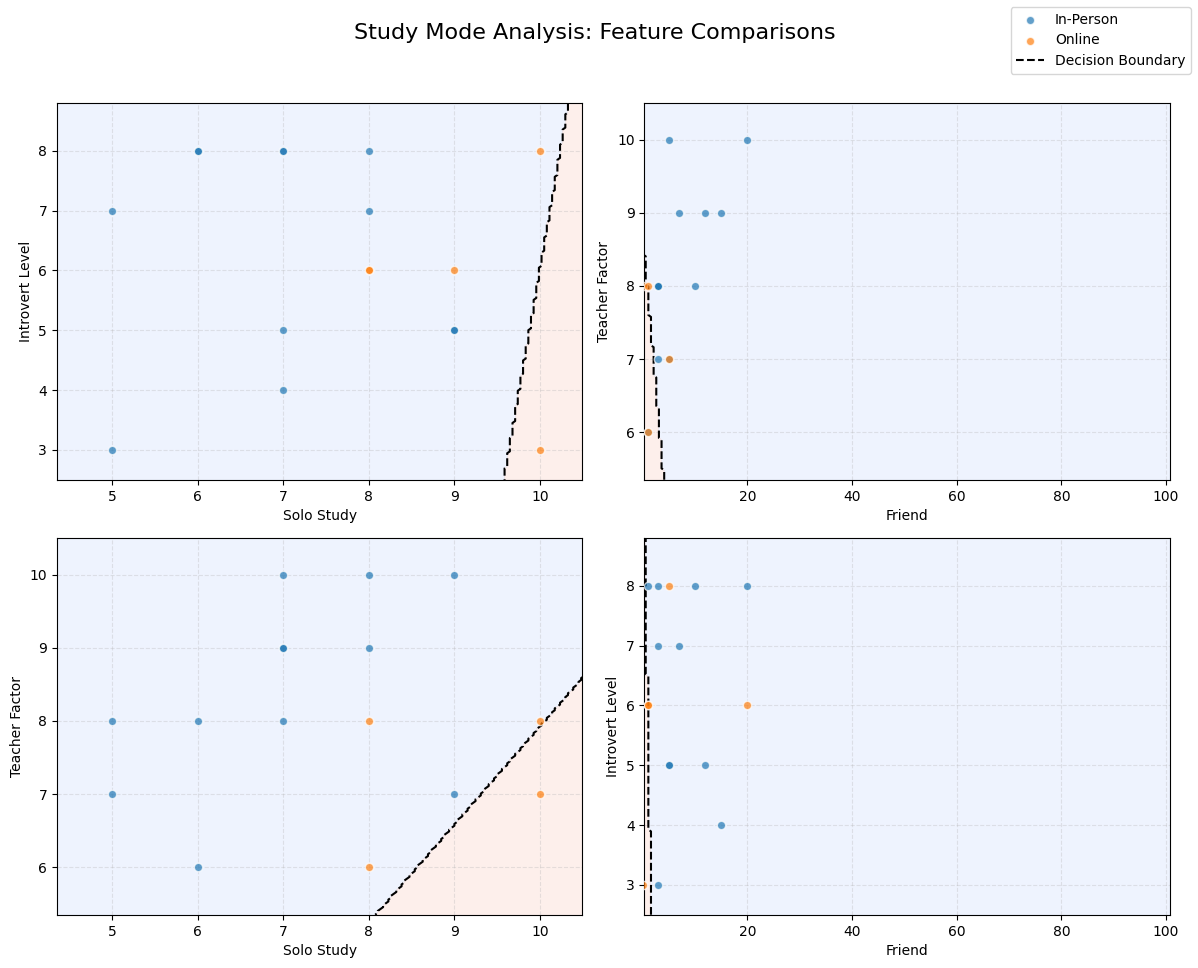

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Study Mode Analysis: Feature Comparisons', fontsize=16)

feature_names = ['friend', 'solo_study', 'teacher_factor', 'introvert_level']
feature_means = df[feature_names].median()  # median instead of mean, safer with outliers

pairs = [
    ('solo_study', 'introvert_level'),
    ('friend', 'teacher_factor'),
    ('solo_study', 'teacher_factor'),
    ('friend', 'introvert_level')
]

for i, ax in enumerate(axes.flat):
    x_feat, y_feat = pairs[i]
    xi = feature_names.index(x_feat)
    yi = feature_names.index(y_feat)

    # Use quantile-based limits to handle extreme values — no data removed!
    x_lim = (df[x_feat].quantile(0.05) - 0.5, df[x_feat].quantile(0.95) + 0.5)
    y_lim = (df[y_feat].quantile(0.05) - 0.5, df[y_feat].quantile(0.95) + 0.5)

    # Build a 2D grid within the visible range
    xx, yy = np.meshgrid(np.linspace(x_lim[0], x_lim[1], 200),
                         np.linspace(y_lim[0], y_lim[1], 200))

    # Fill in the other 2 features with their median
    grid_4d = np.zeros((xx.ravel().shape[0], 4))
    for j, fname in enumerate(feature_names):
        if j == xi:
            grid_4d[:, j] = xx.ravel()
        elif j == yi:
            grid_4d[:, j] = yy.ravel()
        else:
            grid_4d[:, j] = feature_means[fname]

    # Predict on the grid
    Z = predict(grid_4d, final_w, final_b).reshape(xx.shape)

    # Shaded regions
    ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
    # Decision boundary line
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=1.5)

    # Scatter points
    ax.scatter(df[df['study_mode'] == 0][x_feat],
               df[df['study_mode'] == 0][y_feat],
               c='tab:blue', label='In-Person', alpha=0.7, edgecolors='w', zorder=3)
    ax.scatter(df[df['study_mode'] == 1][x_feat],
               df[df['study_mode'] == 1][y_feat],
               c='tab:orange', label='Online', alpha=0.7, edgecolors='w', zorder=3)

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_xlabel(x_feat.replace('_', ' ').title())
    ax.set_ylabel(y_feat.replace('_', ' ').title())
    ax.grid(True, linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
# Add decision boundary to legend manually
from matplotlib.lines import Line2D
handles += [Line2D([0], [0], color='black', linestyle='--', linewidth=1.5)]
labels += ['Decision Boundary']

fig.legend(handles, labels, loc='upper right')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()